In [22]:
# Imports
import os
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


Load dataset from local path

In [23]:
# Load dataset from local path
ROOT_DIR = r"C:\Users\USER\PycharmProjects\DSGP15_Project\ml-models\dataset\Dataset"

EMOTION_TRAIN_CSV_PATH = os.path.join(ROOT_DIR, "Texts", "Emotion", "Emotion_Train.csv")
EMOTION_TEST_CSV_PATH = os.path.join(ROOT_DIR, "Texts", "Emotion", "Emotion_Test.csv")

emo_train = pd.read_csv(EMOTION_TRAIN_CSV_PATH, header=None)
emo_train.columns = ['ImageID', 'Desc_Turk', 'Desc_Eng', 'Emotion', 'Invalid']

# Fix incorrectly placed English descriptions
mask = emo_train['Invalid'].notnull()
emo_train.loc[mask, 'Desc_Eng'] = emo_train.loc[mask, 'Invalid']
emo_train = emo_train.drop(columns=['Invalid'])

emo_test = pd.read_csv(EMOTION_TEST_CSV_PATH, header=None)
emo_test.columns = ['ImageID', 'Desc_Turk', 'Desc_Eng', 'Emotion']


Prepare training data

In [24]:
# Prepare training and validation data
train_df = emo_train[['Desc_Eng', 'Emotion']].dropna()
test_df = emo_test[['Desc_Eng', 'Emotion']].dropna()

# Encode emotion labels as integers
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['Emotion'])
test_df['label'] = le.transform(test_df['Emotion'])

# Split training into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    train_df['Desc_Eng'],
    train_df['label'],
    test_size=0.2,
    random_state=42
)


## Tokenize text using BERT

In [25]:
# Tokenize text using DistilBERT
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=64)


C:\Users\USER\PycharmProjects\DSGP15_Project\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Create PyTorch dataset class

In [26]:
# Create PyTorch dataset class
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = EmotionDataset(train_encodings, list(y_train))
val_dataset = EmotionDataset(val_encodings, list(y_val))


Build BERT model

In [27]:
# Build DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training arguments

In [28]:
# Define CPU-optimized training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,  # keep 1 epoch for CPU testing
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    logging_steps=10,
    save_steps=1000,
    save_total_limit=1,
    no_cuda=True,  # force CPU
    report_to="none",  # disable logging
    disable_tqdm=False
)


C:\Users\USER\PycharmProjects\DSGP15_Project\.venv\Lib\site-packages\transformers\training_args.py:1636: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(


Train the model

In [29]:
# Train the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()
trainer.evaluate()


Step,Training Loss
10,0.678300
20,0.571500
30,0.396000
40,0.247600
50,0.105100
60,0.226200
70,0.120400
80,0.103500
90,0.142800
100,0.071400


{'eval_loss': 0.1113961711525917,
 'eval_runtime': 109.2773,
 'eval_samples_per_second': 16.893,
 'eval_steps_per_second': 1.062,
 'epoch': 1.0}

Prediction function

In [30]:
# Prediction function using trained model
device = "cpu"
model.to(device)


def predict_emotion(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred_id = torch.argmax(logits, dim=1).item()
    return le.inverse_transform([pred_id])[0]


GET PREDICTIONS FROM THE TRAINED MODEL

In [31]:
# Get predictions on validation set
val_outputs = trainer.predict(val_dataset)

y_val_true = y_val.values
y_val_pred = np.argmax(val_outputs.predictions, axis=1)
y_val_probs = torch.softmax(torch.tensor(val_outputs.predictions), dim=1).numpy()


CLASSIFICATION REPORT

In [32]:
# Classification report
print("Classification Report:\n")
print(classification_report(
    y_val_true,
    y_val_pred,
    target_names=le.classes_
))


Classification Report:

              precision    recall  f1-score   support

   Happiness       0.97      0.97      0.97       927
     Sadness       0.97      0.97      0.97       919

    accuracy                           0.97      1846
   macro avg       0.97      0.97      0.97      1846
weighted avg       0.97      0.97      0.97      1846



CONFUSION MATRIX

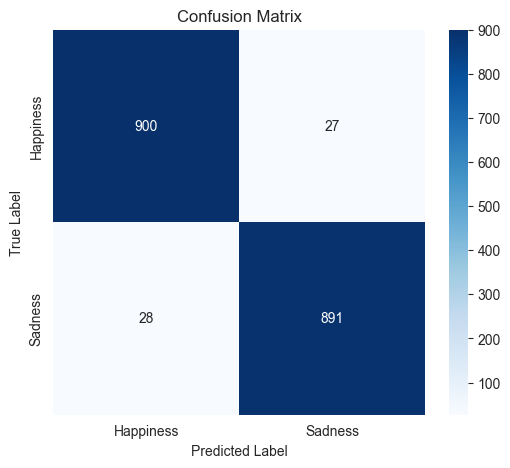

In [33]:
# Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


ROC CURVE

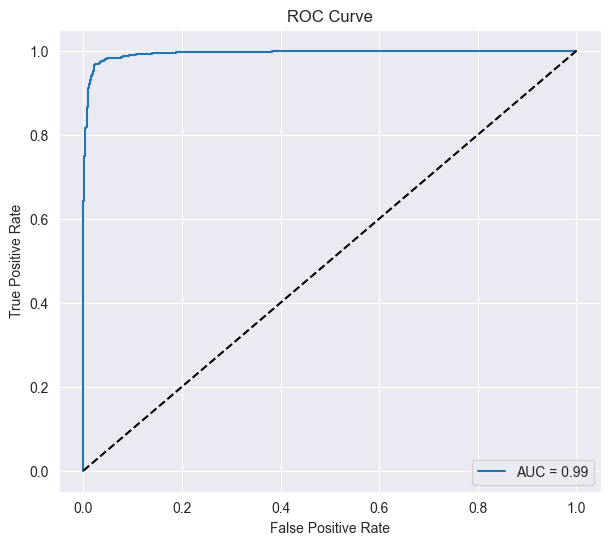

In [34]:
# ROC curve
plt.figure(figsize=(7, 6))

if len(le.classes_) == 2:
    # Binary classification
    fpr, tpr, _ = roc_curve(y_val_true, y_val_probs[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
else:
    # Multiclass ROC
    for i, label in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_val_true == i, y_val_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [35]:
# Test predictions
print(predict_emotion("The child looks very happy and excited"))
print(predict_emotion("The drawing shows sadness and fear"))
print(predict_emotion("This picture feels angry and dark"))


Happiness
Sadness
Sadness
